In [ ]:
import numpy as np
import torch
import sys
import os
from torch.utils.data import DataLoader, IterableDataset

import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score,
    precision_score,
    recall_score,
)

project_root = "/mnt/sunxh/sunxh/wattmamba"
sys.path.insert(0, project_root)
os.chdir(project_root)
print(os.getcwd())
from model.model import WaveCrossMamba, AnomalyDetectionModel

kmer_encode_dic = {'A': 0, "C": 1, "G": 2, "T": 3}


class PredictIterableDataset(IterableDataset):
    def __init__(self, file_path):
        super(PredictIterableDataset, self).__init__()
        self.file_path = file_path

    def parse_line(self, line):
        items = line.strip().split("\t")
        if len(items) < 14:
            print(f"[警告] 行字段数量不足: {len(items)}，跳过")
            return None

        try:
            read_id = items[0]
            contig = items[1]
            position = items[2]
            motif = items[3]

            signal = np.array([float(x) for x in "|".join(items[9:14]).split("|")])
            kmer = np.array([kmer_encode_dic[base] for base in motif])
            mean = np.array([float(x) for x in items[4].split("|")])
            std = np.array([float(x) for x in items[5].split("|")])
            intense = np.array([float(x) for x in items[6].split("|")])
            dwell = np.array([float(x) for x in items[7].split("|")]) / 200.0
            base_quality = np.array([float(x) for x in items[8].split("|")]) / 40.0

            x = [
                torch.tensor(signal, dtype=torch.float32).unsqueeze(0).unsqueeze(2),
                torch.tensor(kmer, dtype=torch.long),
                torch.tensor(mean, dtype=torch.float32),
                torch.tensor(std, dtype=torch.float32),
                torch.tensor(intense, dtype=torch.float32),
                torch.tensor(dwell, dtype=torch.float32),
                torch.tensor(base_quality, dtype=torch.float32),
            ]

            y = "|".join([contig, position, motif, read_id])
            return x, y

        except Exception as e:
            print(f"[错误] 解析失败: {e}")
            return None

    def __iter__(self):
        with open(self.file_path, "r") as f:
            for i, line in enumerate(f):
                result = self.parse_line(line)
                if result is not None:
                    yield result
                else:
                    print(f"[跳过] 第{i + 1}行无法解析")


def build_coverage_dict(m6a_file, normala_file):

    dfs = []
    for fp in [m6a_file, normala_file]:
        df = pd.read_csv(fp, sep="\t", header=None, usecols=[0, 1, 2, 3])
        df = df.rename(columns={0: "read_id", 1: "contig", 2: "pos", 3: "motif"})
        df["read_id"] = df["read_id"].astype(str)
        df["contig"] = df["contig"].astype(str)
        df["pos"] = df["pos"].astype(str)
        df["motif"] = df["motif"].astype(str)
        dfs.append(df)

    full = pd.concat(dfs, ignore_index=True)

    cov_df = (
        full.groupby(["contig", "pos", "motif"])["read_id"]
        .nunique()
        .reset_index()
        .rename(columns={"read_id": "coverage"})
    )

    coverage_dict = {}
    for _, row in cov_df.iterrows():
        key = (row["contig"], row["pos"], row["motif"])
        coverage_dict[key] = int(row["coverage"])

    print("[信息] coverage_dict 构建完成，位点数:", len(coverage_dict))
    return coverage_dict


def predict_model(pretrain_model,
                  model,
                  m6a_loader,
                  normala_loader,
                  device,
                  output_predict,
                  coverage_dict=None):

    model.to(device)
    pretrain_model.to(device)
    model.eval()
    pretrain_model.eval()

    label_dict = {0: "unmod", 1: "mod"}

    all_labels = []
    all_preds = []
    all_probs = []
    all_cov = []

    with open(output_predict, "w") as predict_result:
        print(
            "contig\tposition\tmotif\tread_id\ttrue_label\tpred_label\tprob\tcoverage",
            file=predict_result,
        )

        with torch.no_grad():
            for loader, true_label in [(m6a_loader, 1), (normala_loader, 0)]:
                for batch_idx, (data, batch_y) in enumerate(loader):
                    x, kmer, mean, std, intense, dwell, base_quality = data

                    x = x.to(device)
                    kmer = kmer.to(device)
                    mean = mean.to(device)
                    std = std.to(device)
                    intense = intense.to(device)
                    dwell = dwell.to(device)
                    base_quality = base_quality.to(device)

                    logits, ff = pretrain_model(
                        x, kmer, mean, std, intense, dwell, base_quality
                    )
                    out = model(logits).to(device)

                    batch_size, out_channels = out.size()
                    out = out.view(batch_size, out_channels)
                    out = torch.softmax(out, dim=1)

                    pred = torch.max(out, 1)[1].cpu().numpy()  # 0/1
                    probabilities = out.detach().cpu().numpy()[:, 1]  # P(mod)

                    for j in range(len(batch_y)):
                        contig, position, motif, read_id = batch_y[j].split("|")
                        key = (contig, position, motif)
                        cov = coverage_dict.get(key, 0) if coverage_dict is not None else 0

                        y_true = true_label
                        y_pred = int(pred[j])
                        prob = float(probabilities[j])

                        all_labels.append(y_true)
                        all_preds.append(y_pred)
                        all_probs.append(prob)
                        all_cov.append(cov)

                        print(
                            "%s\t%s\t%s\t%s\t%s\t%s\t%.6f\t%d"
                            % (
                                contig,
                                position,
                                motif,
                                read_id,
                                label_dict[y_true],
                                label_dict[y_pred],
                                prob,
                                cov,
                            ),
                            file=predict_result,
                        )

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    cm = confusion_matrix(all_labels, all_preds)
    print("\n[性能] 混淆矩阵:")
    print(cm)

    print("\n[性能] 分类报告:")
    print(classification_report(all_labels, all_preds, target_names=["unmod", "mod"]))

    roc_auc = roc_auc_score(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)

    prec_05 = precision_score(all_labels, (all_probs >= 0.5).astype(int))
    rec_05 = recall_score(all_labels, (all_probs >= 0.5).astype(int))
    f1_05 = f1_score(all_labels, (all_probs >= 0.5).astype(int))

    print(f"[性能] ROC-AUC: {roc_auc:.4f}")
    print(f"[性能] PR-AUC:  {pr_auc:.4f}")
    print(f"[性能] @0.5 阈值下 Precision: {prec_05:.4f}, Recall: {rec_05:.4f}, F1: {f1_05:.4f}")

    return all_labels, all_preds, all_probs, np.array(all_cov)


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    m6a_file = args.m6a
    normala_file = args.normala

    coverage_dict = build_coverage_dict(m6a_file, normala_file)

    m6a_dataset = PredictIterableDataset(m6a_file)
    normala_dataset = PredictIterableDataset(normala_file)

    m6a_loader = DataLoader(
        dataset=m6a_dataset,
        batch_size=20000,
        num_workers=4,
        pin_memory=True,
    )
    normala_loader = DataLoader(
        dataset=normala_dataset,
        batch_size=20000,
        num_workers=4,
        pin_memory=True,
    )

    print("测试数据加载完成。")

    pretrained_feature_extractor = WaveCrossMamba(device=device, d_model=128).to(device)
    fine_tune_model = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)

    pretrained_feature_extractor.load_state_dict(
        torch.load(
            "/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_RNA004_m6a.pth",
            map_location=device,
        )
    )
    fine_tune_model.load_state_dict(
        torch.load(
            "/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_RNA004_m6a.pth",
            map_location=device,
        )
    )

    print("开始评估二分类异常检测模型...")
    predict_model(
        pretrained_feature_extractor,
        fine_tune_model,
        m6a_loader,
        normala_loader,
        device,
        args.o,
        coverage_dict=coverage_dict,
    )
    print(f"预测完成，生成文件 {args.o}")


class Args:
    def __init__(self):
        self.m6a = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m6A_test.tsv"
        self.normala = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normala_test.tsv"
        self.o = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/m6A_predict.with_cov.tsv"

args = Args()
main(args)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

pred_file = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/m6A_predict.with_cov.tsv"
df = pd.read_csv(pred_file, sep="\t")

label_map = {"unmod": 0, "mod": 1}
df["y_true"] = df["true_label"].map(label_map).astype(int)

print(df.head())
print(df["true_label"].value_counts())
print("coverage 描述：")
print(df["coverage"].describe())


               contig  position  motif                               read_id  \
0  cc6m_2595_t7_ecorv        36  CAAAA  67e030c7-04fa-4be1-bf04-11f9dd2f7924   
1  cc6m_2595_t7_ecorv        37  AAAAC  67e030c7-04fa-4be1-bf04-11f9dd2f7924   
2  cc6m_2595_t7_ecorv       142  CTAGA  67e030c7-04fa-4be1-bf04-11f9dd2f7924   
3  cc6m_2595_t7_ecorv       148  TGATT  67e030c7-04fa-4be1-bf04-11f9dd2f7924   
4  cc6m_2595_t7_ecorv       153  CAATG  67e030c7-04fa-4be1-bf04-11f9dd2f7924   

  true_label pred_label      prob  coverage  y_true  
0        mod        mod  0.961120         1       1  
1        mod        mod  0.983489         2       1  
2        mod        mod  0.948048        10       1  
3        mod        mod  0.994861         9       1  
4        mod        mod  0.974358        11       1  
true_label
mod      440352
unmod    439928
Name: count, dtype: int64
coverage 描述：
count    880280.000000
mean          8.325760
std          10.994594
min           1.000000
25%           2.00000

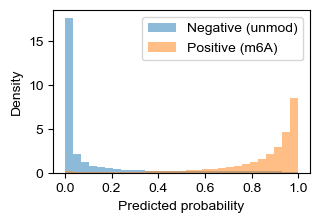

In [39]:
import matplotlib

matplotlib.rcParams["font.family"] = "Arial"

pos = df[df["y_true"] == 1]["prob"].values
neg = df[df["y_true"] == 0]["prob"].values

bins = np.linspace(0, 1, 30)

plt.figure(figsize=(3.3, 2.33))
plt.hist(neg, bins=bins, density=True, alpha=0.5, label="Negative (unmod)")
plt.hist(pos, bins=bins, density=True, alpha=0.5, label="Positive (m6A)")

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_prob_density.pdf", dpi=1200, bbox_inches="tight")
plt.show()


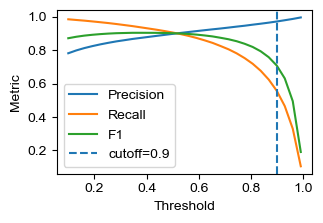

In [40]:
probs  = df["prob"].values
labels = df["y_true"].values
matplotlib.rcParams["font.family"] = "Arial"

thresholds = np.linspace(0.1, 0.99, 30)

prec_list, rec_list, f1_list = [], [], []

for th in thresholds:
    preds = (probs >= th).astype(int)

    if preds.sum() == 0:
        prec = 0.0
        f1   = 0.0
    else:
        prec = precision_score(labels, preds)
        f1   = f1_score(labels, preds)
    rec = recall_score(labels, preds)

    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

plt.figure(figsize=(3.33, 2.33))
plt.plot(thresholds, prec_list, label="Precision")
plt.plot(thresholds, rec_list, label="Recall")
plt.plot(thresholds, f1_list,   label="F1")

CUR_TH = 0.9
plt.axvline(CUR_TH, linestyle="--", label=f"cutoff={CUR_TH}")

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_threshold_metric.pdf", dpi=1200, bbox_inches="tight")
plt.show()


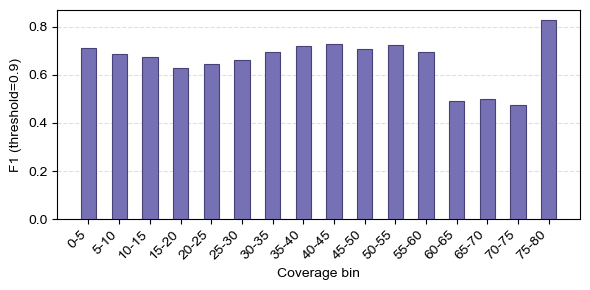

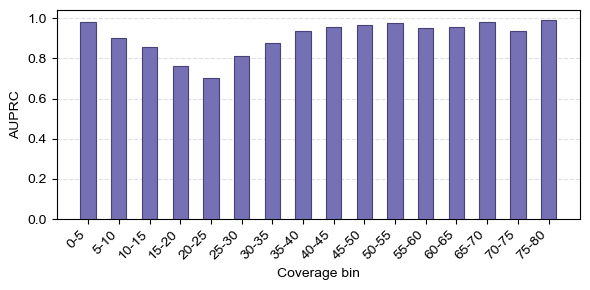

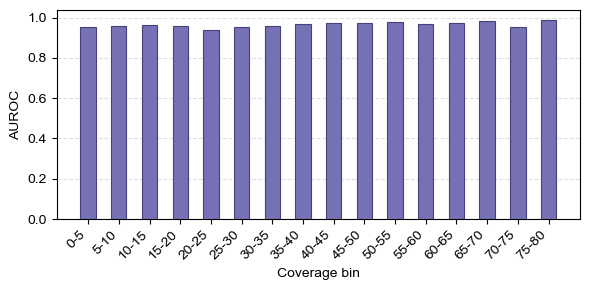

In [41]:
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Arial"

probs  = df["prob"].values
labels = df["y_true"].values

edges = list(range(0, 85, 5))
bins_cov  = [(edges[i], edges[i+1]) for i in range(len(edges) - 1)]
bin_names = [f"{low}-{high}" for (low, high) in bins_cov]

f1_vals    = []
auprc_vals = []
auroc_vals = []
reliable   = []

TH_FOR_F1 = 0.9
MIN_N     = 50

for (low, high), name in zip(bins_cov, bin_names):
    sub = df[(df["coverage"] >= low) & (df["coverage"] < high)]
    n = len(sub)

    if n < MIN_N:
        f1_vals.append(0.0)
        auprc_vals.append(0.0)
        auroc_vals.append(0.0)
        reliable.append(False)
        print(f"{name}: 样本数 {n}，< {MIN_N}，仅作参考")
        continue

    y_true = sub["y_true"].values
    y_prob = sub["prob"].values
    y_pred = (y_prob >= TH_FOR_F1).astype(int)

    f1    = f1_score(y_true, y_pred)
    auprc = average_precision_score(y_true, y_prob)
    auroc = roc_auc_score(y_true, y_prob)

    f1_vals.append(f1)
    auprc_vals.append(auprc)
    auroc_vals.append(auroc)
    reliable.append(True)

x = np.arange(len(bin_names))

main_color  = (118/255, 113/255, 180/255)
light_color = (210/255, 208/255, 230/255)

bar_colors = [main_color if r else light_color for r in reliable]

bar_width = 0.5

# F1 vs coverage bin
plt.figure(figsize=(6, 3))
plt.bar(
    x, f1_vals, width=bar_width, color=bar_colors,
    edgecolor=(70/255, 65/255, 120/255), linewidth=0.8, zorder=3
)
plt.xticks(x, bin_names, rotation=45, ha="right")
plt.xlabel("Coverage bin")
plt.ylabel(f"F1 (threshold={TH_FOR_F1})")
plt.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_F1.pdf", dpi=1200, bbox_inches="tight")
plt.show()

# AUPRC vs coverage bin
plt.figure(figsize=(6, 3))
plt.bar(
    x, auprc_vals, width=bar_width, color=bar_colors,
    edgecolor=(70/255, 65/255, 120/255), linewidth=0.8, zorder=3
)
plt.xticks(x, bin_names, rotation=45, ha="right")
plt.xlabel("Coverage bin")
plt.ylabel("AUPRC")
plt.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_AUPRC.pdf", dpi=1200, bbox_inches="tight")

plt.show()

# AUROC vs coverage bin
plt.figure(figsize=(6, 3))
plt.bar(
    x, auroc_vals, width=bar_width, color=bar_colors,
    edgecolor=(70/255, 65/255, 120/255), linewidth=0.8, zorder=3
)
plt.xticks(x, bin_names, rotation=45, ha="right")
plt.xlabel("Coverage bin")
plt.ylabel("AUROC")
plt.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_ROC.pdf", dpi=1200, bbox_inches="tight")

plt.show()

In [42]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Arial"

pred_file = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/m6A_predict.with_cov.tsv"
df = pd.read_csv(pred_file, sep="\t")

label_map = {"unmod": 0, "mod": 1}
df["y_true"] = df["true_label"].map(label_map).astype(int)

def is_drach(motif: str) -> bool:
    motif = str(motif).upper()
    if len(motif) != 5:
        return False
    D = set("AGT")
    R = set("AG")
    H = set("ACT")
    return (motif[0] in D and
            motif[1] in R and
            motif[2] == "A" and
            motif[3] == "C" and
            motif[4] in H)

df["is_drach"] = df["motif"].apply(is_drach)

print("DRACH 行数:", df["is_drach"].sum())
print("非 DRACH 行数:", (~df["is_drach"]).sum())


DRACH 行数: 68556
非 DRACH 行数: 811724


In [43]:
site_df = (
    df.groupby(["contig", "position", "motif", "is_drach"], as_index=False)
      .agg(
          mean_prob=("prob", "mean"),
          n_reads=("prob", "size"),
          coverage=("coverage", "max"),
          meth_rate=("y_true", "mean"),
      )
)

COV_TH_SITE = 10
site_df = site_df[site_df["coverage"] >= COV_TH_SITE].copy()
print("位点级（coverage≥10）数量:", len(site_df))

drach_probs = site_df[site_df["is_drach"]]["mean_prob"].values
other_probs = site_df[~site_df["is_drach"]]["mean_prob"].values

print("DRACH 位点数:", len(drach_probs))
print("非 DRACH 位点数:", len(other_probs))


位点级（coverage≥10）数量: 3444
DRACH 位点数: 267
非 DRACH 位点数: 3177


In [44]:
import itertools

D = ["A", "G", "T"]
R = ["A", "G"]
H = ["A", "C", "T"]

drach_list = []
for d in D:
    for r in R:
        for h in H:
            drach_list.append(d + r + "A" + "C" + h)

print(len(drach_list), drach_list)


18 ['AAACA', 'AAACC', 'AAACT', 'AGACA', 'AGACC', 'AGACT', 'GAACA', 'GAACC', 'GAACT', 'GGACA', 'GGACC', 'GGACT', 'TAACA', 'TAACC', 'TAACT', 'TGACA', 'TGACC', 'TGACT']


In [45]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Arial"

pred_file = "/mnt/sunxh/Datasets_RNA/curlcake_RNA004/m6A_predict.with_cov.tsv"
df = pd.read_csv(pred_file, sep="\t")

label_map = {"unmod": 0, "mod": 1}
df["y_true"] = df["true_label"].map(label_map).astype(int)

COV_TH_READ = 5
df = df[df["coverage"] >= COV_TH_READ].copy()
print("读段级过滤后样本数:", len(df))

site_df = (
    df.groupby(["contig", "position", "motif"], as_index=False)
      .agg(
          mean_prob=("prob", "mean"),
          coverage=("coverage", "max"),
          meth_rate=("y_true", "mean"),
      )
)

COV_TH_SITE = 10
site_df = site_df[site_df["coverage"] >= COV_TH_SITE].copy()
print("位点级（coverage ≥ %d）数量:" % COV_TH_SITE, len(site_df))

drach_site = site_df[site_df["motif"].isin(drach_list)].copy()
print("DRACH 位点总数:", len(drach_site))

print("各 DRACH motif 的位点数：")
print(drach_site.groupby("motif")["mean_prob"].size().sort_index())


读段级过滤后样本数: 415552
位点级（coverage ≥ 10）数量: 3444
DRACH 位点总数: 267
各 DRACH motif 的位点数：
motif
AAACA    13
AAACC    14
AAACT    14
AGACA    14
AGACC    10
AGACT    19
GAACA    14
GAACC    17
GAACT    12
GGACA    17
GGACC    19
GGACT    22
TAACA    18
TAACC    12
TAACT    22
TGACA     7
TGACC     6
TGACT    17
Name: mean_prob, dtype: int64


/tmp/ipykernel_48441/1963936515.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


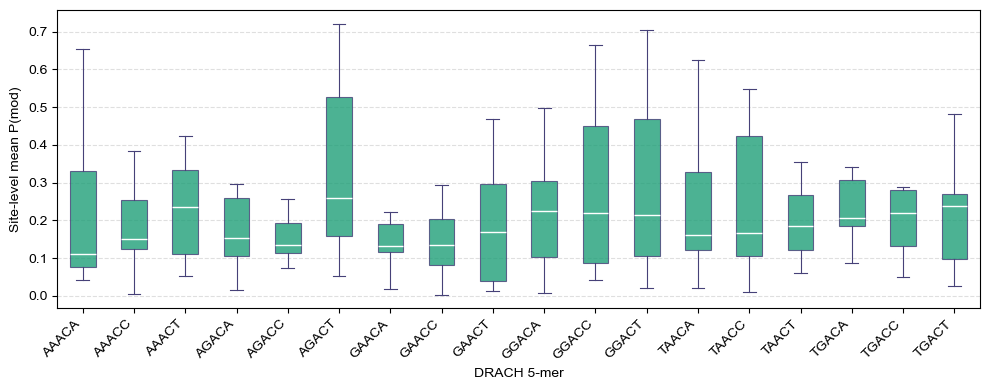

In [46]:
motif_order = sorted(drach_list)

data = [
    drach_site[drach_site["motif"] == m]["mean_prob"].values
    for m in motif_order
]

fig, ax = plt.subplots(figsize=(max(10, 0.5 * len(motif_order)), 4))

bp = ax.boxplot(
    data,
    labels=motif_order,
    patch_artist=True,
    showfliers=False,
)

main_color  = (31/255, 159/255, 120/255)
edge_color  = (70/255,  65/255,  120/255)

for box in bp["boxes"]:
    box.set(facecolor=main_color, alpha=0.8, edgecolor=edge_color, linewidth=0.8)
for whisker in bp["whiskers"]:
    whisker.set(color=edge_color, linewidth=0.8)
for cap in bp["caps"]:
    cap.set(color=edge_color, linewidth=0.8)
for median in bp["medians"]:
    median.set(color="white", linewidth=1.0)

ax.set_xlabel("DRACH 5-mer")
ax.set_ylabel("Site-level mean P(mod)")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_drach_boxplot.pdf", dpi=1200, bbox_inches="tight")
plt.show()
